# <center> Car Sales Data Analysis <center>

## Load & Inspect

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
df = pd.read_csv('car_sale_data.csv')

In [4]:
df

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,12/31/2023,Martin,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,60504-7114,Passenger,8583598,Pasco
23902,C_CND_023903,12/31/2023,Jimmy,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,DoubleÂ Overhead Camshaft,Auto,Black,16000,06457-3834,Hardtop,7914229,Middletown
23903,C_CND_023904,12/31/2023,Emma,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,99301-3882,Sedan,7659127,Scottsdale
23904,C_CND_023905,12/31/2023,Victoire,Male,13500,Chrysler Plymouth,Chevrolet,Metro,DoubleÂ Overhead Camshaft,Auto,Black,31000,53546-9427,Passenger,6030764,Austin


In [5]:
df.shape

(23906, 16)

In [6]:
df.columns.tolist()

['Car_id',
 'Date',
 'Customer Name',
 'Gender',
 'Annual Income',
 'Dealer_Name',
 'Company',
 'Model',
 'Engine',
 'Transmission',
 'Color',
 'Price ($)',
 'Dealer_No ',
 'Body Style',
 'Phone',
 'Dealer_Region']

In [7]:
df.dtypes

Car_id             str
Date               str
Customer Name      str
Gender             str
Annual Income    int64
Dealer_Name        str
Company            str
Model              str
Engine             str
Transmission       str
Color              str
Price ($)        int64
Dealer_No          str
Body Style         str
Phone            int64
Dealer_Region      str
dtype: object

In [8]:
df.isnull().sum()

Car_id           0
Date             0
Customer Name    1
Gender           0
Annual Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price ($)        0
Dealer_No        0
Body Style       0
Phone            0
Dealer_Region    0
dtype: int64

In [9]:
df[df.duplicated()]

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region


## Cleaning

In [10]:
df.rename(
    columns={'Dealer_No ': 'Dealer_No',
             'Customer Name': 'Customer_Name',
             'Annual Income':'Annual_Income',
             'Body Style': 'Body_Style',
             'Price ($)': 'Price'},
    inplace=True
) 

In [11]:
df['Date'] = pd.to_datetime(df['Date'])

In [12]:
df.dtypes

Car_id                      str
Date             datetime64[us]
Customer_Name               str
Gender                      str
Annual_Income             int64
Dealer_Name                 str
Company                     str
Model                       str
Engine                      str
Transmission                str
Color                       str
Price                     int64
Dealer_No                   str
Body_Style                  str
Phone                     int64
Dealer_Region               str
dtype: object

In [13]:
df['Engine'] = df['Engine'].str.replace('Â', '', regex=False)

In [14]:
df.drop(columns=['Phone','Dealer_No', 'Customer_Name'], inplace=True)

## Exploration

In [15]:
df

,Car_id,Date,Gender,Annual_Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price,Body_Style,Dealer_Region
0,C_CND_000001,2022-01-02,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,Double Overhead Camshaft,Auto,Black,26000,SUV,Middletown
1,C_CND_000002,2022-01-02,Male,1480000,C & M Motors Inc,Dodge,Durango,Double Overhead Camshaft,Auto,Black,19000,SUV,Aurora
2,C_CND_000003,2022-01-02,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,Passenger,Greenville
3,C_CND_000004,2022-01-02,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,SUV,Pasco
4,C_CND_000005,2022-01-02,Male,1465000,Chrysler Plymouth,Acura,TL,Double Overhead Camshaft,Auto,Red,24500,Hatchback,Janesville
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23901,C_CND_023902,2023-12-31,Male,13500,C & M Motors Inc,Plymouth,Voyager,Overhead Camshaft,Manual,Red,12000,Passenger,Pasco
23902,C_CND_023903,2023-12-31,Female,900000,Ryder Truck Rental and Leasing,Chevrolet,Prizm,Double Overhead Camshaft,Auto,Black,16000,Hardtop,Middletown
23903,C_CND_023904,2023-12-31,Male,705000,Chrysler of Tri-Cities,BMW,328i,Overhead Camshaft,Manual,Red,21000,Sedan,Scottsdale
23904,C_CND_023905,2023-12-31,Male,13500,Chrysler Plymouth,Chevrolet,Metro,Double Overhead Camshaft,Auto,Black,31000,Passenger,Austin


In [16]:
df['Company'].value_counts()

Company
Chevrolet     1819
Dodge         1671
Ford          1614
Volkswagen    1333
Mercedes-B    1285
Mitsubishi    1277
Chrysler      1120
Oldsmobile    1111
Toyota        1110
Nissan         886
Mercury        874
Lexus          802
Pontiac        796
BMW            790
Volvo          789
Honda          708
Acura          689
Cadillac       652
Plymouth       617
Saturn         586
Lincoln        492
Audi           468
Buick          439
Subaru         405
Jeep           363
Porsche        361
Hyundai        264
Saab           210
Infiniti       195
Jaguar         180
Name: count, dtype: int64

In [17]:
df['Body_Style'].value_counts()

Body_Style
SUV          6374
Hatchback    6128
Sedan        4488
Passenger    3945
Hardtop      2971
Name: count, dtype: int64

In [18]:
df['Dealer_Region'].value_counts()

Dealer_Region
Austin        4135
Janesville    3821
Scottsdale    3433
Pasco         3131
Aurora        3130
Middletown    3128
Greenville    3128
Name: count, dtype: int64

In [19]:
df['Engine'].value_counts()

Engine
Double Overhead Camshaft    12571
Overhead Camshaft           11335
Name: count, dtype: int64

In [20]:
df['Annual_Income'].describe()

count    2.390600e+04
mean     8.308403e+05
std      7.200064e+05
min      1.008000e+04
25%      3.860000e+05
50%      7.350000e+05
75%      1.175750e+06
max      1.120000e+07
Name: Annual_Income, dtype: float64

In [21]:
df['Price'].describe()

count    23906.000000
mean     28090.247846
std      14788.687608
min       1200.000000
25%      18001.000000
50%      23000.000000
75%      34000.000000
max      85800.000000
Name: Price, dtype: float64

In [22]:
df.groupby(['Company','Model']).size().sort_values(ascending= False)

Company     Model        
Mitsubishi  Diamante         418
Oldsmobile  Silhouette       411
Chevrolet   Prizm            411
Volkswagen  Passat           391
Dodge       Ram Pickup       383
                            ... 
Mitsubishi  Mirage            19
Oldsmobile  Alero             18
Lexus       RX300             15
Toyota      Avalon            15
Chrysler    Sebring Conv.     10
Length: 155, dtype: int64

In [23]:
df['Gender'].value_counts(normalize=True).mul(100).round(2)

Gender
Male      78.63
Female    21.37
Name: proportion, dtype: float64

In [24]:
df['Dealer_Name'].value_counts()

Dealer_Name
Progressive Shippers Cooperative Association No    1318
Rabun Used Car Sales                               1313
Race Car Help                                      1253
Saab-Belle Dodge                                   1251
Star Enterprises Inc                               1249
Tri-State Mack Inc                                 1249
Ryder Truck Rental and Leasing                     1248
U-Haul CO                                          1247
Scrivener Performance Engineering                  1246
Suburban Ford                                      1243
Nebo Chevrolet                                      633
Pars Auto Sales                                     630
Hatfield Volkswagen                                 629
McKinney Dodge Chrysler Jeep                        629
New Castle Ford Lincoln Mercury                     629
Capitol KIA                                         628
Gartner Buick Hyundai Saab                          628
Pitre Buick-Pontiac-Gmc of Scottsdal

In [25]:
df[df['Dealer_Region'] == 'Austin'].groupby('Dealer_Name').size().sort_values(ascending = False).head()

Dealer_Name
Race Car Help                  1019
U-Haul CO                      1008
Motor Vehicle Branch Office     514
Clay Johnson Auto Sales         510
Rabun Used Car Sales            154
dtype: int64

In [26]:
df[df['Dealer_Region'] == 'Janesville'].groupby('Dealer_Name').size().sort_values(ascending = False).head()

Dealer_Name
Progressive Shippers Cooperative Association No    1069
Suburban Ford                                      1004
Iceberg Rentals                                     515
Chrysler Plymouth                                   503
Saab-Belle Dodge                                     57
dtype: int64

## Insights

* Most sales are for Chevrolet cars. Although Dodge and Ford have close sales to Chevrolet compared to the rest. Most people are buying these American cars from our company. 

* Customers are more attracted to SUV and Hatchback types.

* Customer annual income ranges from 10K USD to 11.2M USD. The median income is 735K USD, meaning half of customers earn
  below this. The mean (830K USD) is dragged up by high earners and is not representative of a typical customer.

* Car prices range from 1,200 to 85,800 dollars. Most cars are less than or equal to 34,000 dollars and the average price is 28,090.

* Austin and Janesville are the regions that our company had the most sales.

* Mitsubishi Diamante is the most sold car.  

* 78% of customers are male 

* Dealers split into two performance tiers: top dealers with 1,200–1,350 sales and smaller dealers with 600–650 sales.

* "Race Car Help" & "U-Haul CO" dealers are the top sellers in Austin and "Progressive Shippers Cooperative Association" & "Suburban Ford" dealers are the top sellers in Janesville.

## Visuals

In [27]:
df['Date'].dt.year.unique()

array([2022, 2023], dtype=int32)

In [28]:
df['Year_Month'] = df['Date'].dt.to_period('M')

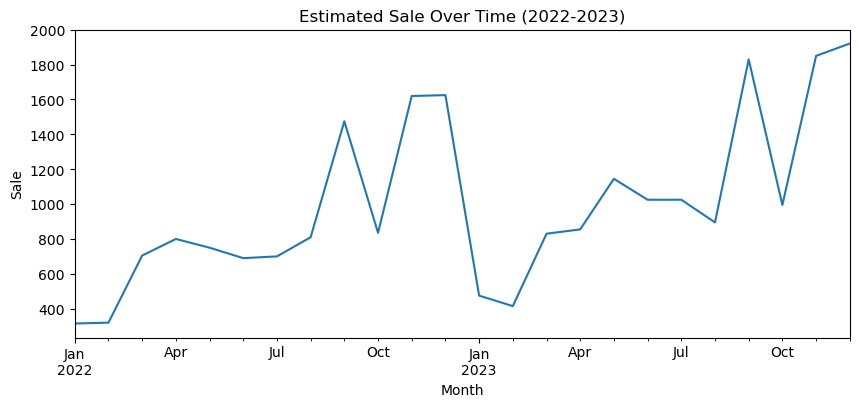

In [29]:
plt.figure(figsize=(10,4))

df.groupby('Year_Month').size().plot()
plt.xlabel('Month')
plt.ylabel('Sale')
plt.title('Estimated Sale Over Time (2022-2023)')
plt.show()

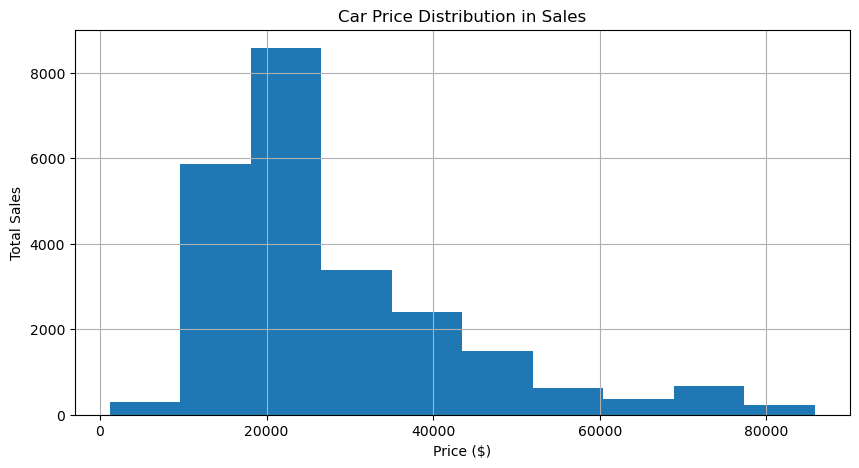

In [30]:
plt.figure(figsize=(10,5))

df['Price'].hist()
plt.xlabel('Price ($)')
plt.ylabel('Total Sales')
plt.title('Car Price Distribution in Sales')
plt.show()

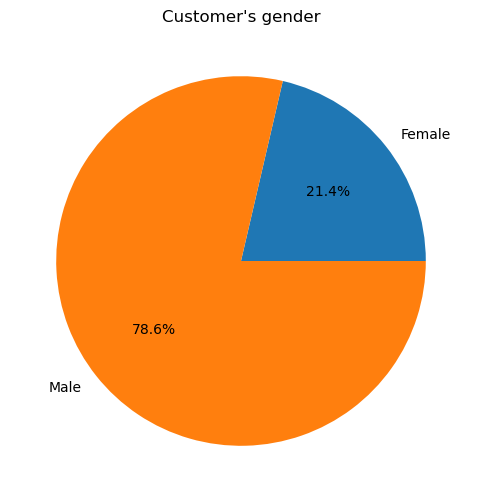

In [31]:
plt.figure(figsize=(10,6))

gender_df = df.groupby('Gender').size()
plt.pie(gender_df, labels=gender_df.index, autopct='%1.1f%%')
plt.title("Customer's gender")
plt.show()

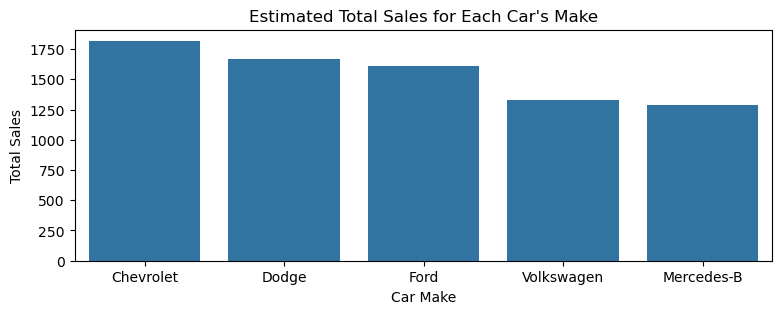

In [32]:
plt.figure(figsize=(9,3))

car_company_df = df['Company'].value_counts().head()

sns.barplot(x= car_company_df.index, y=car_company_df.values)
plt.xlabel('Car Make')
plt.ylabel('Total Sales')
plt.title("Estimated Total Sales for Each Car's Make")
plt.show()

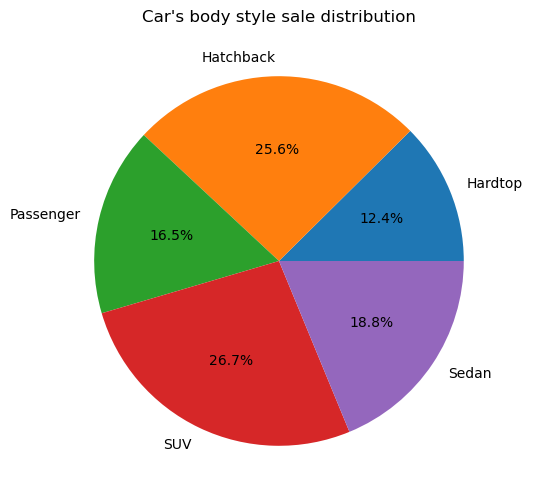

In [33]:
plt.figure(figsize=(10,6))

car_style_df = df.groupby('Body_Style').size()
plt.pie(car_style_df, labels=car_style_df.index, autopct='%1.1f%%')
plt.title("Car's body style sale distribution")
plt.show()

## Conclusion

The company can invest in these four dealers more than the others: "Race Car Help", "U-Haul CO", "Progressive Shippers Cooperative Association", and "Suburban Ford" because they are the top sellers in the highest sales regions. Dealers should fill 50% of their space with Hatchback and SUV cars and the other 50% with Passenger, Hardtop, and Sedan. Buying priority should be with Chevrolet, Dodge, and Ford. According to the charts, 1 in 5 customers is female.